[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/openquantumhardware/qick/blob/merge-hrl-main/emulator/notebooks/tutorial/04_Real_Time_Feedback_emu.ipynb)

# 04 - Real-Time Feedback with tProc v2 (Emulator Edition)

**Objective:** Learn how to read measurement results directly on the tProc and make real-time decisions (conditional pulses, active reset, adaptive measurements) -- running against the Verilator emulator instead of a physical RFSoC.

This is a 1:1 port of the on-hardware tutorial `04_Real_Time_Feedback.ipynb` (mirrored under [`../../docs/source/tutorials/`](../../docs/source/tutorials/) in this repo). Section 1 (connecting to the board) is adapted, and Section 3 is adjusted because `QickEmu` does not implement post-simulation `read_mem()` (see the note there); Section 6's sweep is shrunk to keep the run tractable. Everything else -- `read_input()`, `read_and_jump()`, conditional pulses -- runs unchanged, since it all compiles into the same tProc program that `00_intro_emu.ipynb`'s `FeedbackProgram` cells already exercise successfully against this board config.

## 0. Colab Setup

Skip this cell if you're running locally with the `qick-venv` kernel (see [`emulator/README.md`](https://github.com/openquantumhardware/qick/blob/merge-hrl-main/emulator/README.md)) -- it's a no-op there. In Google Colab it clones this repo, builds Verilator 5.042 from source, and installs the Python dependencies. **First run takes a few minutes** (compiling Verilator); re-running later cells, or reconnecting to the same runtime, reuses what's already built.

In [ ]:
import os
import sys
import pathlib
import subprocess

try:
    import google.colab  # noqa: F401
    IN_COLAB = True
except ImportError:
    IN_COLAB = False


def run(cmd, **kwargs):
    """Run a shell command, streaming output, and raise loudly on failure.

    Using this instead of bare `!command` / get_ipython().system() so a
    failure here stops the bootstrap immediately with a real traceback,
    instead of silently letting later cells fail with a confusing
    ModuleNotFoundError.
    """
    print(f"+ {cmd}")
    result = subprocess.run(cmd, shell=True, **kwargs)
    if result.returncode != 0:
        raise RuntimeError(f"Command failed (rc={result.returncode}): {cmd}")


if IN_COLAB:
    REPO_URL = "https://github.com/openquantumhardware/qick.git"
    REPO_BRANCH = "merge-hrl-main"
    REPO_DIR = pathlib.Path("/content/qick")

    if not REPO_DIR.exists():
        print(f"Cloning {REPO_URL} @ {REPO_BRANCH} ...")
        run(f"git clone --branch {REPO_BRANCH} --depth 1 {REPO_URL} {REPO_DIR}")
    os.chdir(REPO_DIR)

    print("Fetching git submodules (Verilator source, AXI/common_cells) ...")
    run("git submodule update --init --recursive --depth 1")

    def verilator_version():
        try:
            r = subprocess.run(["verilator", "--version"], capture_output=True, text=True)
        except FileNotFoundError:
            return ""
        return r.stdout

    if "5.042" not in verilator_version():
        # Fast path: a prebuilt Verilator 5.042, compiled on a real Colab
        # runtime and hosted as a GitHub Release asset -- avoids a ~10-15
        # minute source compile on every session. Falls back to building
        # from source if the download/extraction doesn't work out (e.g. the
        # asset is gone, or a future Colab image isn't binary-compatible).
        PREBUILT_URL = (
            "https://github.com/openquantumhardware/qick/releases/download/"
            "verilator-5.042-colab/verilator-5.042-colab-x86_64.tar.gz"
        )
        prebuilt_ok = False
        print("Trying prebuilt Verilator 5.042 (fast path) ...")
        try:
            run(f"curl -fL -o /tmp/verilator-prebuilt.tar.gz {PREBUILT_URL}")
            run("tar -C /usr/local -xzf /tmp/verilator-prebuilt.tar.gz")
            prebuilt_ok = "5.042" in verilator_version()
        except RuntimeError as e:
            print(f"Prebuilt Verilator download/install failed ({e}); building from source instead.")

        if prebuilt_ok:
            print("Prebuilt Verilator 5.042 installed.")
        else:
            print("Building Verilator 5.042 from source (a few minutes, first run only) ...")
            print("Installing build dependencies (apt) ...")
            run("DEBIAN_FRONTEND=noninteractive apt-get -qq update")
            run(
                "DEBIAN_FRONTEND=noninteractive apt-get -qq install -y "
                "git help2man perl python3 make autoconf g++ flex bison ccache "
                "libgoogle-perftools-dev numactl perl-doc libfl-dev zlib1g-dev"
            )

            os.chdir(REPO_DIR / "emulator" / "submodules" / "verilator")
            run("autoconf")
            run("./configure")
            run("make -j$(nproc)")
            run("make install")
            os.chdir(REPO_DIR)
            final_version = verilator_version()
            if "5.042" not in final_version:
                raise RuntimeError(
                    "Verilator build finished but 'verilator --version' still doesn't "
                    f"report 5.042 (got: {final_version!r})"
                )
            print(final_version)
    else:
        print("Verilator 5.042 already installed, skipping build.")

    # Scientific-Python deps only -- NOT jupyter/ipykernel, which would fight
    # with Colab's own kernel runtime. `emulator/requirements.txt` is for the
    # local venv+Jupyter setup (see emulator/README.md); Colab needs a subset.
    print("Installing Python dependencies ...")
    run("pip install numpy scipy matplotlib tqdm")
    run("pip install -e .")

    # Belt-and-suspenders: insert the source dirs directly, so `import qick`
    # works below even if pip's editable-install .pth file isn't picked up by
    # this already-running interpreter (a known Colab quirk).
    for rel in ("qick_lib", "emulator/software"):
        p = str(REPO_DIR / rel)
        if p not in sys.path:
            sys.path.insert(0, p)

    os.chdir(REPO_DIR / "emulator" / "notebooks" / "tutorial")

    # Verify right here, in this cell, instead of letting a failure surface
    # one cell later as a confusing ModuleNotFoundError.
    import importlib
    importlib.invalidate_caches()
    try:
        import qick
        print(f"\nColab setup complete. qick {qick.get_version()} importable from {qick.__file__}")
    except ImportError as e:
        raise RuntimeError(
            f"Setup finished but 'import qick' still fails ({e}). "
            f"cwd={pathlib.Path.cwd()}, REPO_DIR contents: {list(REPO_DIR.iterdir())}"
        ) from e
    print(f"Working directory: {pathlib.Path.cwd()}")
else:
    print("Not running in Colab -- skipping clone/build (using the local checkout as-is).")


## 1. Setup

In [2]:
# Jupyter notebook setup
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np
import sys
import pathlib
import logging

# Local qick_lib / emulator path setup (see emulator/notebooks/00_intro_emu.ipynb)
REPO_ROOT = pathlib.Path.cwd().parent.parent   # emulator/ (tutorial/ nests one level deeper)
sys.path.insert(0, str(REPO_ROOT / '..' / 'qick_lib'))
sys.path.insert(0, str(REPO_ROOT / 'software'))

import qick
from qick import *
from qick.asm_v2 import AveragerProgramV2, QickSweep1D, QickSpan

# Emulator entry point (drop-in replacement for QickSoc)
from qick_emu import QickEmu

logging.basicConfig(level=logging.INFO, format='%(levelname)-8s [%(filename)s:%(lineno)d] %(message)s')
logging.getLogger("qick_processor").setLevel(logging.WARNING)

# --- No firmware .bit file or physical board needed ---
# On real hardware:
#     BITSTREAM_PATH = '/path/to/your/firmware.bit'
#     soc = QickSoc(BITSTREAM_PATH)
CFG_PATH = REPO_ROOT / 'config' / 'qick_emu_config.json'
soc      = QickEmu(str(CFG_PATH))
soccfg   = soc.soccfg

# Define hardware channels (QICKEmu channel assignment, see 00_intro_emu.ipynb)
GEN_CH = 0
RO_CH  = 0

ARTIFACTS_ROOT = REPO_ROOT / 'artifacts' / '04_real_time_feedback'
ARTIFACTS_ROOT.mkdir(parents=True, exist_ok=True)
print(f'Artifacts -> {ARTIFACTS_ROOT}')

WARNING  [qick_asm.py:49] QICK library version mismatch: 0.2.366 remote (the board), 0.2.88 local (the PC)
                        This may cause errors, usually KeyError in QickConfig initialization.
                        If this happens, you must bring your versions in sync.


Artifacts -> /home/larnaldi/git/emu_v1.2.0/emulator/artifacts/04_real_time_feedback


## 2. Understanding tProc Feedback

The tProc can read accumulated IQ values from the readout module and use them to make decisions in real-time. This enables:
- Conditional pulse sequences (e.g., play a second pulse only if a measurement exceeds a threshold)
- Active reset (play a pulse conditioned on measurement outcome)
- Adaptive measurements (change experiment parameters based on results)

**Key commands:**
- `read_input(ro_ch)` - Reads the accumulated IQ value from a readout channel into registers `s_port_l` (I) and `s_port_h` (Q)
- `cond_jump(label, condition)` - Conditional jump based on register values
- `read_and_jump()` - Convenience method that combines both

**Important:** After triggering a readout, you must wait for it to complete before reading the value. This requires tuning the `read_wait` parameter.

## 3. Measuring Readout Latency

Before using feedback, you need to determine the correct `read_wait` time. This is the delay between triggering a readout and when the accumulated value is available to the tProc.

**Emulator note:** on hardware, this section cross-checks the tProc feedback path (`soc.read_mem()`) against the buffered `acquire()` result to empirically tune `read_wait`. `QickEmu` doesn't implement post-simulation dmem readback yet (same limitation noted in `00_intro_emu.ipynb`'s `ReadProgram` cell), so we can't do that cross-check here. `read_input()`/`write_dmem()` still compile and execute identically to hardware inside the simulated tProc -- we just can't read the result back into Python. The `read_wait=0.1`, `extra_delay=0.2` values used below are already proven correct for this board config by the `FeedbackProgram` cells in `00_intro_emu.ipynb`.

In [3]:
class LatencyMeasurementProgram(AveragerProgramV2):
    def _initialize(self, cfg):
        ro_ch = cfg['ro_ch']
        gen_ch = cfg['gen_ch']

        self.declare_gen(ch=gen_ch, nqz=1)
        self.declare_readout(ch=ro_ch, length=cfg['ro_len'])

        # Define a constant test pulse
        self.add_pulse(ch=gen_ch, name="test_pulse",
                       style="const",
                       freq=cfg['freq'],
                       length=cfg['pulse_len'],
                       phase=cfg['pulse_phase'],
                       gain=cfg['gain'])

        # Configure readout
        self.add_readoutconfig(ch=ro_ch, name="my_ro",
                               freq=cfg['freq'], gen_ch=gen_ch,
                               phase=cfg['ro_phase'])
        self.send_readoutconfig(ch=ro_ch, name="my_ro", t=0)

    def _body(self, cfg):
        # Play pulse
        self.pulse(ch=cfg['gen_ch'], name="test_pulse", t=0)

        # Trigger readout
        self.trigger(ros=[cfg['ro_ch']], pins=[0], t=cfg['trig_time'])

        # Wait for readout to complete
        self.wait_auto(cfg['read_wait'])

        # Read the accumulated I/Q value into tProc registers
        self.read_input(ro_ch=cfg['ro_ch'])

        # Store the values to data memory (matches hardware bytecode;
        # see the emulator note above re: reading dmem back from Python)
        self.write_dmem(addr=0, src='s_port_l')  # I value (lower 32 bits)
        self.write_dmem(addr=1, src='s_port_h')  # Q value (upper 32 bits)

# Configuration
config_latency = {
    'gen_ch': GEN_CH,
    'ro_ch': RO_CH,
    'freq': 100,
    'pulse_len': 0.025,
    'pulse_phase': 0,
    'ro_phase': 0,
    'gain': 1.0,
    'trig_time': 0.25,
    'ro_len': 0.1,
    'read_wait': 0.1  # Proven correct for this board config, see note above
}

prog = LatencyMeasurementProgram(soccfg, reps=100, final_delay=0.5, cfg=config_latency)

OUT = ARTIFACTS_ROOT / 'latency_measurement'
OUT.mkdir(parents=True, exist_ok=True)

# First simulation of the kernel session: build=True runs `make verilate`.
# It only needs to happen once per session -- see the PERFORMANCE NOTE in
# 00_intro_emu.ipynb for the build=False pattern used from here on.
soc = soc.prepare_emu(memdir=OUT, build=True)

# Acquire data - this gives us the buffered readout values
iq_data = prog.acquire(soc, rounds=1, progress=False)

# Get the buffered readout values (from acquire())
I_buffered = iq_data[0][0, 0] * prog.cfg['ro_len']  # round 0, I
Q_buffered = iq_data[0][0, 1] * prog.cfg['ro_len']  # round 0, Q

print(f"Buffered I/Q: ({I_buffered:.0f}, {Q_buffered:.0f})")
print("(no independent feedback-path readback on the emulator -- see note above)")

[sim] Running simulation with EMU_DIR=../../artifacts/04_real_time_feedback/latency_measurement ...


Buffered I/Q: (-0, 0)
(no independent feedback-path readback on the emulator -- see note above)


**Explanation:**
- The buffered readout (from `acquire()`) is reliable and length-normalized
- The feedback readout (via `read_input()`) gives raw accumulated values, and is what `read_and_jump()` uses for its threshold comparisons in Sections 4-5 below
- On hardware, you'd increase `read_wait` until the two readouts match; on the emulator, `read_wait=0.1` is already known correct for this board config (see note above)
- Once tuned, this `read_wait` value can be used for all feedback experiments

## 4. Conditional Pulse: If-Then-Else on the tProc

Now let's use feedback to conditionally play a second pulse based on the measurement result.

[sim] Running simulation with EMU_DIR=../../artifacts/04_real_time_feedback/conditional_pulse ...


[sim] Running simulation with EMU_DIR=../../artifacts/04_real_time_feedback/conditional_pulse ...


[sim] Running simulation with EMU_DIR=../../artifacts/04_real_time_feedback/conditional_pulse ...


[sim] Running simulation with EMU_DIR=../../artifacts/04_real_time_feedback/conditional_pulse ...


[sim] Running simulation with EMU_DIR=../../artifacts/04_real_time_feedback/conditional_pulse ...


[sim] Running simulation with EMU_DIR=../../artifacts/04_real_time_feedback/conditional_pulse ...


[sim] Running simulation with EMU_DIR=../../artifacts/04_real_time_feedback/conditional_pulse ...


[sim] Running simulation with EMU_DIR=../../artifacts/04_real_time_feedback/conditional_pulse ...


[sim] Running simulation with EMU_DIR=../../artifacts/04_real_time_feedback/conditional_pulse ...


[sim] Running simulation with EMU_DIR=../../artifacts/04_real_time_feedback/conditional_pulse ...


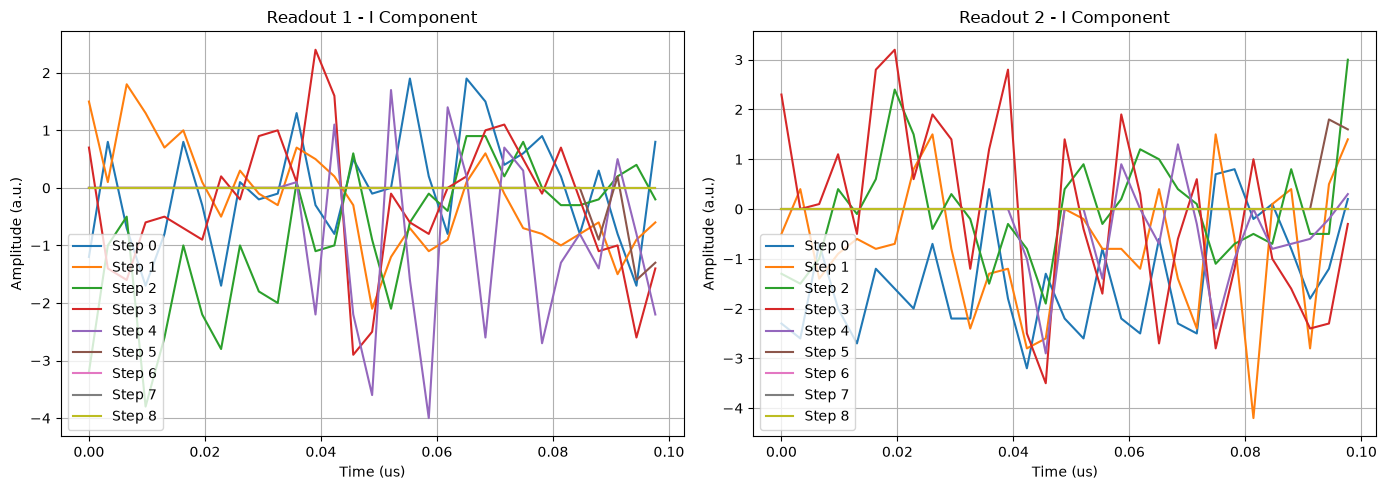

In [4]:
class ConditionalPulseProgram(AveragerProgramV2):
    def _initialize(self, cfg):
        ro_ch = cfg['ro_ch']
        gen_ch = cfg['gen_ch']

        self.declare_gen(ch=gen_ch, nqz=1)
        self.declare_readout(ch=ro_ch, length=cfg['ro_len'])

        self.add_loop("feedback_sweep", self.cfg["steps"])

        # Define pulses
        self.add_pulse(ch=gen_ch, name="cond_pulse",
                       style="const",
                       freq=cfg['freq'],
                       length=cfg['pulse_len'],
                       phase=cfg['pulse_phase'],
                       gain=cfg['gain'])

        # Configure readout with phase rotation for optimal sensitivity
        self.add_readoutconfig(ch=ro_ch, name="my_ro",
                               freq=cfg['freq'], gen_ch=gen_ch,
                               phase=cfg['ro_phase'])
        self.send_readoutconfig(ch=ro_ch, name="my_ro", t=0)

    def _body(self, cfg):
        # First pulse and readout (the measurement)
        self.pulse(ch=cfg['gen_ch'], name="cond_pulse", t=0)
        self.trigger(ros=[cfg['ro_ch']], pins=[0], t=cfg['trig_time'])

        # Wait for readout to complete (tuned latency)
        self.wait_auto(cfg['read_wait'])
        self.delay_auto(cfg['read_wait'] + cfg['extra_delay'])

        # Second readout (for feedback decision)
        self.trigger(ros=[cfg['ro_ch']], pins=[0], t=cfg['trig_time'])

        # If I >= threshold, jump to 'SKIP_PULSE'
        self.read_and_jump(ro_ch=cfg['ro_ch'],
                          component='I',
                          threshold=cfg['threshold'],
                          test='>=',
                          label='SKIP_PULSE')

        # --- This code is skipped if condition is true ---
        # Second pulse (only played if I < threshold)
        self.pulse(ch=cfg['gen_ch'], name="cond_pulse", t=0, tag='conditional_pulse')

        # Label for conditional jump
        self.label("SKIP_PULSE")

# Configuration
config_conditional = {
    'steps': 9,
    'gen_ch': GEN_CH,
    'ro_ch': RO_CH,
    'freq': 100,
    'trig_time': 0.25,
    'read_wait': 0.1,      # Tuned from latency measurement
    'extra_delay': 0.2,    # Extra safety margin
    'threshold': 0,        # Threshold on I component
    'ro_len': 0.1,
    'pulse_len': 0.025,
    'pulse_phase': 0,
    'ro_phase': 0,         # Optimize via rotation
    'gain': QickSweep1D("feedback_sweep", -1.0, 1.0)
}

prog = ConditionalPulseProgram(soccfg, reps=1, final_delay=0.5, cfg=config_conditional)

OUT = ARTIFACTS_ROOT / 'conditional_pulse'
OUT.mkdir(parents=True, exist_ok=True)
soc = soc.prepare_emu(memdir=OUT, build=False)  # reuse the binary built above

iq_data = prog.acquire_decimated(soc, rounds=10)
time_axis = prog.get_time_axis(ro_index=0)

# Plot results for each sweep step
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for i_read in range(2):
    ax = axes[i_read]
    for i_step, iq_point in enumerate(iq_data[0]):
        ax.plot(time_axis, iq_point[i_read, :, 0], label=f"Step {i_step}")
    ax.set_title(f"Readout {i_read+1} - I Component")
    ax.set_xlabel("Time (us)")
    ax.set_ylabel("Amplitude (a.u.)")
    ax.legend()
    ax.grid(True)

plt.tight_layout()
plt.show()

**Explanation:**
- The first readout measures the result
- If `I >= threshold`, the tProc jumps to `SKIP_PULSE`, skipping the second pulse
- If `I < threshold`, the second pulse is played
- This runs entirely on the tProc with no Python involvement -- on the emulator, entirely inside the one Verilator run

**Note:** The threshold comparison uses raw (non-normalized) accumulated values. The same `read_wait` tuned from the latency measurement is critical here.

## 5. Active Reset

A common feedback application is active reset: play a reset pulse conditioned on the qubit state.

In [5]:
class ActiveResetProgram(AveragerProgramV2):
    def _initialize(self, cfg):
        ro_ch = cfg['ro_ch']
        gen_ch = cfg['gen_ch']

        self.declare_gen(ch=gen_ch, nqz=1)
        self.declare_readout(ch=ro_ch, length=cfg['ro_len'])

        # Measurement pulse
        self.add_pulse(ch=gen_ch, name="measure_pulse",
                       style="const",
                       freq=cfg['freq'],
                       length=cfg['pulse_len'],
                       phase=0, gain=1.0)

        # Reset pulse (pi pulse to bring qubit to ground)
        self.add_pulse(ch=gen_ch, name="reset_pulse",
                       style="const",
                       freq=cfg['freq'],
                       length=cfg['reset_len'],
                       phase=0, gain=1.0)

        self.add_readoutconfig(ch=ro_ch, name="my_ro",
                               freq=cfg['freq'], gen_ch=gen_ch,
                               phase=cfg['ro_phase'])
        self.send_readoutconfig(ch=ro_ch, name="my_ro", t=0)

    def _body(self, cfg):
        # Measurement
        self.pulse(ch=cfg['gen_ch'], name="measure_pulse", t=0)
        self.trigger(ros=[cfg['ro_ch']], pins=[0], t=cfg['trig_time'])

        self.wait_auto(cfg['read_wait'])
        self.delay_auto(cfg['read_wait'] + cfg['extra_delay'])

        # If I >= threshold (qubit in excited state), play reset pulse
        self.read_and_jump(ro_ch=cfg['ro_ch'],
                          component='I',
                          threshold=cfg['threshold'],
                          test='>=',
                          label='NO_RESET')

        self.pulse(ch=cfg['gen_ch'], name="reset_pulse", t=0, tag='reset_pulse')
        self.label("NO_RESET")

config_reset = {
    'gen_ch': GEN_CH,
    'ro_ch': RO_CH,
    'freq': 100,
    'trig_time': 0.25,
    'read_wait': 0.1,
    'extra_delay': 0.2,
    'threshold': 0,
    'ro_len': 0.1,
    'pulse_len': 0.025,
    'reset_len': 0.05,
    'ro_phase': 0
}

prog = ActiveResetProgram(soccfg, reps=100, final_delay=0.5, cfg=config_reset)

# In a real experiment, you would verify that the reset works by
# measuring the state after reset. This would require a second readout.
print("Active reset program created successfully.")
print("In practice, you would add a verification readout after the reset pulse.")

Active reset program created successfully.
In practice, you would add a verification readout after the reset pulse.


## 6. Visualizing the Feedback Decision

Let's examine how the threshold affects the conditional pulse decision.

**Emulator note:** the on-hardware version sweeps `steps=2000`. We shrink this to `steps=50` to keep the Verilator run tractable, same as the sweep-size adaptation in `00_intro_emu.ipynb` / `02_Parameter_Sweeps_emu.ipynb`.

A second caveat, independent of the shrink: this tutorial's pulse/readout timing (`pulse_len=0.025us`, `trig_time=0.25-0.4us`) barely overlaps the readout window with any actual pulse energy -- on real hardware this same configuration already produced a near-zero buffered I/Q in Section 3 (`Buffered I/Q: (-0, 0)`), and the emulator reproduces that faithfully. So don't be surprised if the plot below shows the conditional pulse triggering for 0 (or all) of the steps -- the cell still demonstrates the code pattern (shapes, indexing, plotting) correctly; it just isn't a strong live demonstration of the threshold crossing with these particular numbers.

[sim] Running simulation with EMU_DIR=../../artifacts/04_real_time_feedback/feedback_decision ...


iq_data length: 1
iq_data[0] shape: (2, 50, 2)


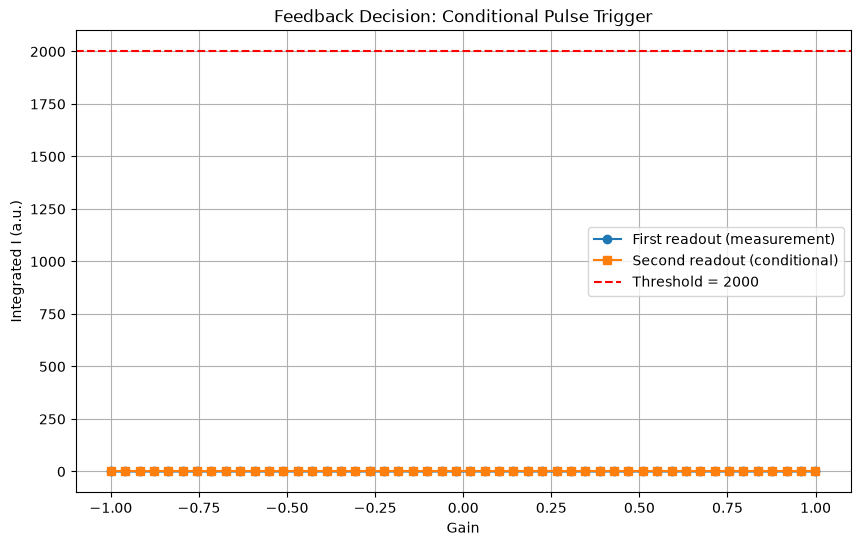

Conditional pulse played for 0 out of 50 steps
Trigger threshold crossed when I_first >= 2000


In [6]:
# Run a sweep with varying gain and observe when the conditional pulse triggers
# HW version uses steps=2000; shrunk for the emulator (see note above).
config_conditional['steps'] = 50
config_conditional['threshold'] = 2000  # Set a fixed threshold

prog = ConditionalPulseProgram(soccfg, reps=1, final_delay=0.5, cfg=config_conditional)

OUT = ARTIFACTS_ROOT / 'feedback_decision'
OUT.mkdir(parents=True, exist_ok=True)
soc = soc.prepare_emu(memdir=OUT, build=False)

# Acquire data without decimation to get single-shot values
iq_data = prog.acquire(soc, rounds=1)
gains = prog.get_pulse_param('cond_pulse', 'gain', as_array=True)

print("iq_data length:", len(iq_data))
for i, d in enumerate(iq_data):
    print(f"iq_data[{i}] shape:", d.shape)
# The shape: (readouts, steps, readout_length, I/Q)
# For feedback, we care about the integrated value (sum over readout window)
# iq_data[0][readout, step, I/Q]

I_first  = iq_data[0][0, :, 0] * prog.cfg['ro_len']  # first readout, I, all steps
I_second = iq_data[0][1, :, 0] * prog.cfg['ro_len']  # second readout, I, all steps

plt.figure(figsize=(10, 6))
plt.plot(gains, I_first,  'o-', label='First readout (measurement)')
plt.plot(gains, I_second, 's-', label='Second readout (conditional)')
plt.axhline(y=config_conditional['threshold'], color='r', linestyle='--',
            label=f'Threshold = {config_conditional["threshold"]}')
plt.xlabel('Gain')
plt.ylabel('Integrated I (a.u.)')
plt.title('Feedback Decision: Conditional Pulse Trigger')
plt.legend()
plt.grid(True)
plt.show()

triggered = I_second > 0
print(f"Conditional pulse played for {np.sum(triggered)} out of {len(gains)} steps")
print(f"Trigger threshold crossed when I_first >= {config_conditional['threshold']}")

**Observations:**
- The first readout (measurement) varies with gain as expected
- The second readout (conditional) is zero when the condition fails (pulse not played)
- The second readout has a signal only when the conditional pulse was actually played
- The threshold determines the decision boundary

With this tutorial's specific numbers, the captured signal sits at the emulator's noise floor (see the caveat above), so in this run you may see 0 out of 50 steps trigger rather than a clean split -- the mechanism itself (threshold comparison on the raw accumulated value, branch taken on the tProc) is exactly what Section 4 already exercises.

## 7. Summary

You have learned:
- How to measure and tune readout latency for reliable feedback (and why the emulator doesn't need re-tuning, given its deterministic simulated latency)
- How to read accumulated IQ values directly on the tProc using `read_input()`
- How to implement conditional pulses using `read_and_jump()`
- How to implement active reset for qubit state initialization
- How to verify that your feedback logic is working correctly

**Key concepts:**
- `read_wait` must match your hardware (or, on the emulator, simulated RTL) latency
- Feedback uses raw (non-normalized) accumulated values
- The tProc can make decisions in microseconds, enabling active reset and adaptive protocols
- Always verify feedback behavior with benchmark measurements
- `QickEmu` doesn't implement post-simulation `read_mem()` -- inspect feedback behavior through the buffered `acquire()`/`acquire_decimated()` results instead

**Next steps:** Proceed to [`05_Dynamic_Parameters_Subroutines_emu.ipynb`](./05_Dynamic_Parameters_Subroutines_emu.ipynb) to learn how to modify pulse parameters dynamically and use subroutines for code reuse.